# **Household hourly energy demand forecast**

**Authors**: *Quentin Bacher, Matteo Beschi, Paul Prata Leal* 

**Course**: *Machine Learning*

This notebook focuses on short-term forecasting of hourly electricity consumption using historical energy data from a household setting.

**Dataset**

The dataset consists of time-indexed power measurements recorded at a minute frequency between December 2006 and November 2010. Raw power values (kW) are converted into energy consumption (kWh) to ensure consistency with standard energy metrics. Missing values (approx. 1,25%) are handled through interpolation, and temporal features are extracted from the datetime index.

Source of dataset: [Kaggle](https://www.kaggle.com/datasets/uciml/electric-power-consumption-data-set/data)

**Objective**

The main objective is to forecast electricity consumption one hour ahead, using only information that would realistically be available at prediction time. The analysis emphasizes avoiding data leakage and ensuring proper temporal validation.

**Models and Baselines**

To assess model performance, several approaches are compared:

- **Random Walk (Persistence) baseline**: assumes next-hour consumption equals the previous hour.

- **Seasonal Naive Baseline**: uses consumption from the same hour in the previous year.

- **SARIMA (Seasonal ARIMA)**: A classical statistical time series model that explicitly models autocorrelation, trends, and seasonal patterns. SARIMA serves as a strong linear baseline and a reference for traditional forecasting approaches.

- **XGBoost Regressor**: a tree-based gradient boosting model using lagged consumption values and calendar-based features.

- **LSTM (Long Short-Term Memory)**: A recurrent neural network designed to model sequential dependencies and non-linear temporal dynamics. LSTM is used to capture complex patterns in consumption behavior over time.

Baselines provide a reference point to evaluate whether more complex models truly capture predictive signal beyond simple heuristics.

**Evaluation**

Model performance is evaluated on a held-out test set using standard regression metrics:

- Mean Absolute Error (MAE)

- Root Mean Squared Error (RMSE)

- Mean Absolute Percentage Error (MAPE)

Visual comparisons are also used to assess how well each model captures daily consumption patterns and short-term dynamics.

### 0. Imports 

In [33]:
# Core
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Model
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor


### 1. Upload data & Parsing

In [34]:
# Read the data
df = pd.read_csv("household_power_consumption.txt", sep=";", low_memory=False)


In [35]:
# Dataset info
print(df.info())

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB
None


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [36]:
df.tail()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
2075254,26/11/2010,20:58:00,0.946,0.000,240.430,4.000,0.000,0.000,0.0
2075255,26/11/2010,20:59:00,0.944,0.000,240.000,4.000,0.000,0.000,0.0
2075256,26/11/2010,21:00:00,0.938,0.000,239.820,3.800,0.000,0.000,0.0
2075257,26/11/2010,21:01:00,0.934,0.000,239.700,3.800,0.000,0.000,0.0
2075258,26/11/2010,21:02:00,0.932,0.000,239.550,3.800,0.000,0.000,0.0


In [37]:
# parsing --> date + time

df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S"
)

# set time index
df = df.set_index("Datetime")
df = df.sort_index()

# Convert the numeric columns into floats
numeric_cols = df.columns.difference(["Date", "Time"])

df[numeric_cols] = df[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)

# check
print(df.info())
df.tail()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 158.3+ MB
None


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,,,
2010-11-26 20:58:00,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2010-11-26 20:59:00,26/11/2010,20:59:00,0.944,0.0,240.00,4.0,0.0,0.0,0.0
2010-11-26 21:00:00,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2010-11-26 21:01:00,26/11/2010,21:01:00,0.934,0.0,239.70,3.8,0.0,0.0,0.0
2010-11-26 21:02:00,26/11/2010,21:02:00,0.932,0.0,239.55,3.8,0.0,0.0,0.0


### 2. Missing data handling

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


<Axes: xlabel='Datetime'>

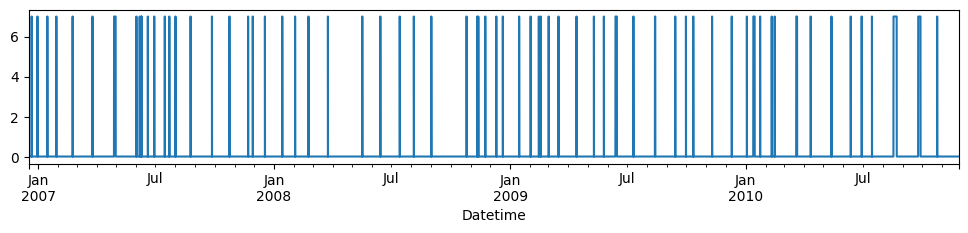

In [38]:
# check missing data
print(df.isnull().sum())

# plot missing data distribution
(df.isna().sum(axis=1)
 .plot(figsize=(12, 2)))

In [39]:
# 1. Identify rows with at least one NaN
nan_mask = df.isna().any(axis=1)

# 2. Find consecutive blocks
# creates a group each time we change state (NaN -> not NaN or viceversa)
groups = (nan_mask != nan_mask.shift()).cumsum()

# 3. Counts the length of each block of NaN
nan_block_lengths = nan_mask.groupby(groups).sum()

# 4. Max, min, mean, median
max_nan_run = nan_block_lengths.max()
mean_nan_run = nan_block_lengths.mean()
median_nan_run = nan_block_lengths.median()

# 5. Beginning date and ending date of the longest block
longest_block = nan_mask.groupby(groups).apply(lambda x: x.index if x.sum() == max_nan_run else None).dropna().iloc[0]

print(f"Longest consecutive NaN period: {max_nan_run} rows")
print(f"From {longest_block[0]} to {longest_block[-1]}")
print(f"\nAverage consecutive NaN rows: {mean_nan_run:.2f}")
print(f"Median consecutive NaN rows: {median_nan_run}")


Longest consecutive NaN period: 7226 rows
From 2010-08-17 21:02:00 to 2010-08-22 21:27:00

Average consecutive NaN rows: 181.67
Median consecutive NaN rows: 0.0


In [40]:
# time interpolation

df['was_interpolated'] = nan_mask

df = df.interpolate(method="time")
print(df.isna().sum())

# Numero totale di righe che contenevano NaN
num_interpolated = df['was_interpolated'].sum()
print(f"Number of rows that were interpolated: {num_interpolated}")

df.info()
df.head()


C:\Users\Matteo\AppData\Local\Temp\ipykernel_20060\3851704155.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method="time")


Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
was_interpolated         0
dtype: int64
Number of rows that were interpolated: 25979
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 10 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
 9   was_interpolated       bool   
dtypes: bool(1), float64(7), object(2)
memory usage: 160.3+ MB


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,was_interpolated
Datetime,,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,False
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,False
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,False
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,False
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,False


Missing values account for approximately 1.25% of the dataset and affect all measurement variables simultaneously.

Missing observations are distributed over time, mostly as isolated points or short consecutive intervals, with the longest consecutive missing period spanning 7,226 rows (from 2010-08-17 21:02:00 to 2010-08-22 21:27:00). The average length of missing blocks is 181.67 rows, and the median is 0 rows, indicating that most missing values are isolated.

Given the regular time index and the limited extent of missingness, time-based linear interpolation was applied prior to dataset splitting. 
Although this may introduce a minor form of temporal leakage, the impact is considered
negligible due to the low proportion of missing values (≈1.25%) and their sparse temporal
distribution. This approach ensures a continuous time series required by classical and
deep learning forecasting models.

Additionally, a boolean flag column `was_interpolated` was added to indicate which rows originally contained missing values.


### 3. Feature engineering
To convert the original power measurements in kW into energy in Wh per minute, we used the formula:

    `Energy (Wh) = Power (kW) × (60/1000)`
- Power is the rate of energy consumption per unit time, expressed in kilowatts (kW).

- Multiplying by 60 converts per-minute measurements to watt-minutes.

- Dividing by 1000 converts watts to watt-hours (Wh), which is the standard unit for energy consumption.

This conversion ensures that all energy-related features are consistent and comparable, and can be meaningfully aggregated across different time intervals (hours, days, weeks) for analysis and forecasting.

In [41]:
# 1) Conversion Power (kW per min) → Energy (Wh per min)
# Global_active_power & Global_reactive_power in kW → Wh per min
df['Global_active_energy'] = df['Global_active_power'] * 1000 / 60
df['Global_reactive_energy'] = df['Global_reactive_power'] * 1000 / 60

# 2) Remaining_submetering
df['Remaining_submetering'] = df['Global_active_energy'] - (
    df['Sub_metering_1'] + df['Sub_metering_2'] + df['Sub_metering_3']
)

# 3) Other temporal features 
df['Hour'] = df.index.hour
df['DayOfWeek'] = df.index.dayofweek   # 0=Monday, 6=Sunday
df['Weekend'] = df['DayOfWeek'].isin([5,6]).astype(int)

# Season 
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Season'] = df.index.month.map(get_season)

# Reorganise columns
order = [
    "Date",
    "Time",
    "Hour",
    "DayOfWeek",
    "Weekend",
    "Season",
    "Global_active_power",
    "Global_active_energy",
    "Global_reactive_power",
    "Global_reactive_energy",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
    "Remaining_submetering",
    "was_interpolated"
]


df = df[order]


# check
print(df.info())
df.head()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Date                    object 
 1   Time                    object 
 2   Hour                    int32  
 3   DayOfWeek               int32  
 4   Weekend                 int64  
 5   Season                  object 
 6   Global_active_power     float64
 7   Global_active_energy    float64
 8   Global_reactive_power   float64
 9   Global_reactive_energy  float64
 10  Voltage                 float64
 11  Global_intensity        float64
 12  Sub_metering_1          float64
 13  Sub_metering_2          float64
 14  Sub_metering_3          float64
 15  Remaining_submetering   float64
 16  was_interpolated        bool   
dtypes: bool(1), float64(10), int32(2), int64(1), object(3)
memory usage: 255.3+ MB
None


,Date,Time,Hour,DayOfWeek,Weekend,Season,Global_active_power,Global_active_energy,Global_reactive_power,Global_reactive_energy,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Remaining_submetering,was_interpolated
Datetime,,,,,,,,,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,17,5,1,Winter,4.216,70.266667,0.418,6.966667,234.84,18.4,0.0,1.0,17.0,52.266667,False
2006-12-16 17:25:00,16/12/2006,17:25:00,17,5,1,Winter,5.360,89.333333,0.436,7.266667,233.63,23.0,0.0,1.0,16.0,72.333333,False
2006-12-16 17:26:00,16/12/2006,17:26:00,17,5,1,Winter,5.374,89.566667,0.498,8.300000,233.29,23.0,0.0,2.0,17.0,70.566667,False
2006-12-16 17:27:00,16/12/2006,17:27:00,17,5,1,Winter,5.388,89.800000,0.502,8.366667,233.74,23.0,0.0,1.0,17.0,71.800000,False
2006-12-16 17:28:00,16/12/2006,17:28:00,17,5,1,Winter,3.666,61.100000,0.528,8.800000,235.68,15.8,0.0,1.0,17.0,43.100000,False


In [42]:
# Save by-minute version 
df_byminute = df.copy()

# Hourly aggregation
df = df.resample("h").agg({
    # Energy variables (sum)
    'Global_active_energy': 'sum',
    'Global_reactive_energy': 'sum',
    'Sub_metering_1': 'sum',
    'Sub_metering_2': 'sum',
    'Sub_metering_3': 'sum',
    'Remaining_submetering': 'sum',

    # Physical averages
    'Voltage': 'mean',
    'Global_intensity': 'mean',

    # Temporal / categorical
    'Date': 'first',
    'Time': 'first',
    'Hour': 'first',
    'DayOfWeek': 'first',
    'Weekend': 'first',
    'Season': 'first',

    # Data quality flag
    'was_interpolated': 'any'
})


# Conversion Wh → kWh for standard interpretation
energy_cols = [
    "Global_active_energy",
    "Global_reactive_energy",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
    "Remaining_submetering"
]

for col in energy_cols:
    df[col + "_kWh"] = df[col] / 1000

# Renaming sub-metering for clarity
df = df.rename(columns={
    "Sub_metering_1_kWh": "kitchen_energy_kwh",
    "Sub_metering_2_kWh": "laundry_energy_kwh",
    "Sub_metering_3_kWh": "climate_energy_kwh",
    "Remaining_submetering_kWh": "other_energy_kwh",
    "Global_active_energy_kWh": "active_energy_kwh",
    "Global_reactive_energy_kWh": "reactive_energy_kwh"
})

# Reorganise columns
order = [
    "Date",
    "Time",
    "Hour",
    "DayOfWeek",
    "Weekend",
    "Season",
    "active_energy_kwh",
    "reactive_energy_kwh",
    "Voltage",
    "Global_intensity",
    "kitchen_energy_kwh",
    "laundry_energy_kwh",
    "climate_energy_kwh",
    "other_energy_kwh",
    "was_interpolated"
]


df = df[order]

# Columns names in lowercase
df.columns = [col.lower() for col in df.columns]

# check
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34589 entries, 2006-12-16 17:00:00 to 2010-11-26 21:00:00
Freq: h
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 34589 non-null  object 
 1   time                 34589 non-null  object 
 2   hour                 34589 non-null  int32  
 3   dayofweek            34589 non-null  int32  
 4   weekend              34589 non-null  int64  
 5   season               34589 non-null  object 
 6   active_energy_kwh    34589 non-null  float64
 7   reactive_energy_kwh  34589 non-null  float64
 8   voltage              34589 non-null  float64
 9   global_intensity     34589 non-null  float64
 10  kitchen_energy_kwh   34589 non-null  float64
 11  laundry_energy_kwh   34589 non-null  float64
 12  climate_energy_kwh   34589 non-null  float64
 13  other_energy_kwh     34589 non-null  float64
 14  was_interpolated     34589 non-null  bool  

,date,time,hour,dayofweek,weekend,season,active_energy_kwh,reactive_energy_kwh,voltage,global_intensity,kitchen_energy_kwh,laundry_energy_kwh,climate_energy_kwh,other_energy_kwh,was_interpolated
Datetime,,,,,,,,,,,,,,,
2006-12-16 17:00:00,16/12/2006,17:24:00,17,5,1,Winter,2.533733,0.137400,234.643889,18.100000,0.0,0.019,0.607,1.907733,False
2006-12-16 18:00:00,16/12/2006,18:00:00,18,5,1,Winter,3.632200,0.080033,234.580167,15.600000,0.0,0.403,1.012,2.217200,False
2006-12-16 19:00:00,16/12/2006,19:00:00,19,5,1,Winter,3.400233,0.085233,233.232500,14.503333,0.0,0.086,1.001,2.313233,False
2006-12-16 20:00:00,16/12/2006,20:00:00,20,5,1,Winter,3.268567,0.075100,234.071500,13.916667,0.0,0.000,1.007,2.261567,False
2006-12-16 21:00:00,16/12/2006,21:00:00,21,5,1,Winter,3.056467,0.076667,237.158667,13.046667,0.0,0.025,1.033,1.998467,False


### 4. Exploratory Data Analysis

In [43]:
# descriptive statistics
num_var = df[['active_energy_kwh', 'reactive_energy_kwh', 'voltage', 
              'global_intensity', 'kitchen_energy_kwh', 'laundry_energy_kwh',
              'climate_energy_kwh', 'other_energy_kwh']]

num_var.describe()

,active_energy_kwh,reactive_energy_kwh,voltage,global_intensity,kitchen_energy_kwh,laundry_energy_kwh,climate_energy_kwh,other_energy_kwh
count,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000
mean,1.090237,0.123644,240.832682,4.621615,0.066566,0.077351,0.386528,0.559792
std,0.894216,0.067069,3.001576,3.743583,0.211103,0.250098,0.440442,0.494604
min,0.046733,0.000000,225.834500,0.503333,0.000000,0.000000,0.000000,0.046733
25%,0.342867,0.077933,239.178167,1.516667,0.000000,0.000000,0.039000,0.261833
50%,0.803216,0.107133,240.974667,3.423333,0.000000,0.020000,0.099000,0.348000
75%,1.578700,0.149500,242.689000,6.603333,0.000000,0.039000,0.845000,0.669500
max,6.560533,0.774333,251.902000,28.383333,2.902000,2.786000,1.471470,3.890233


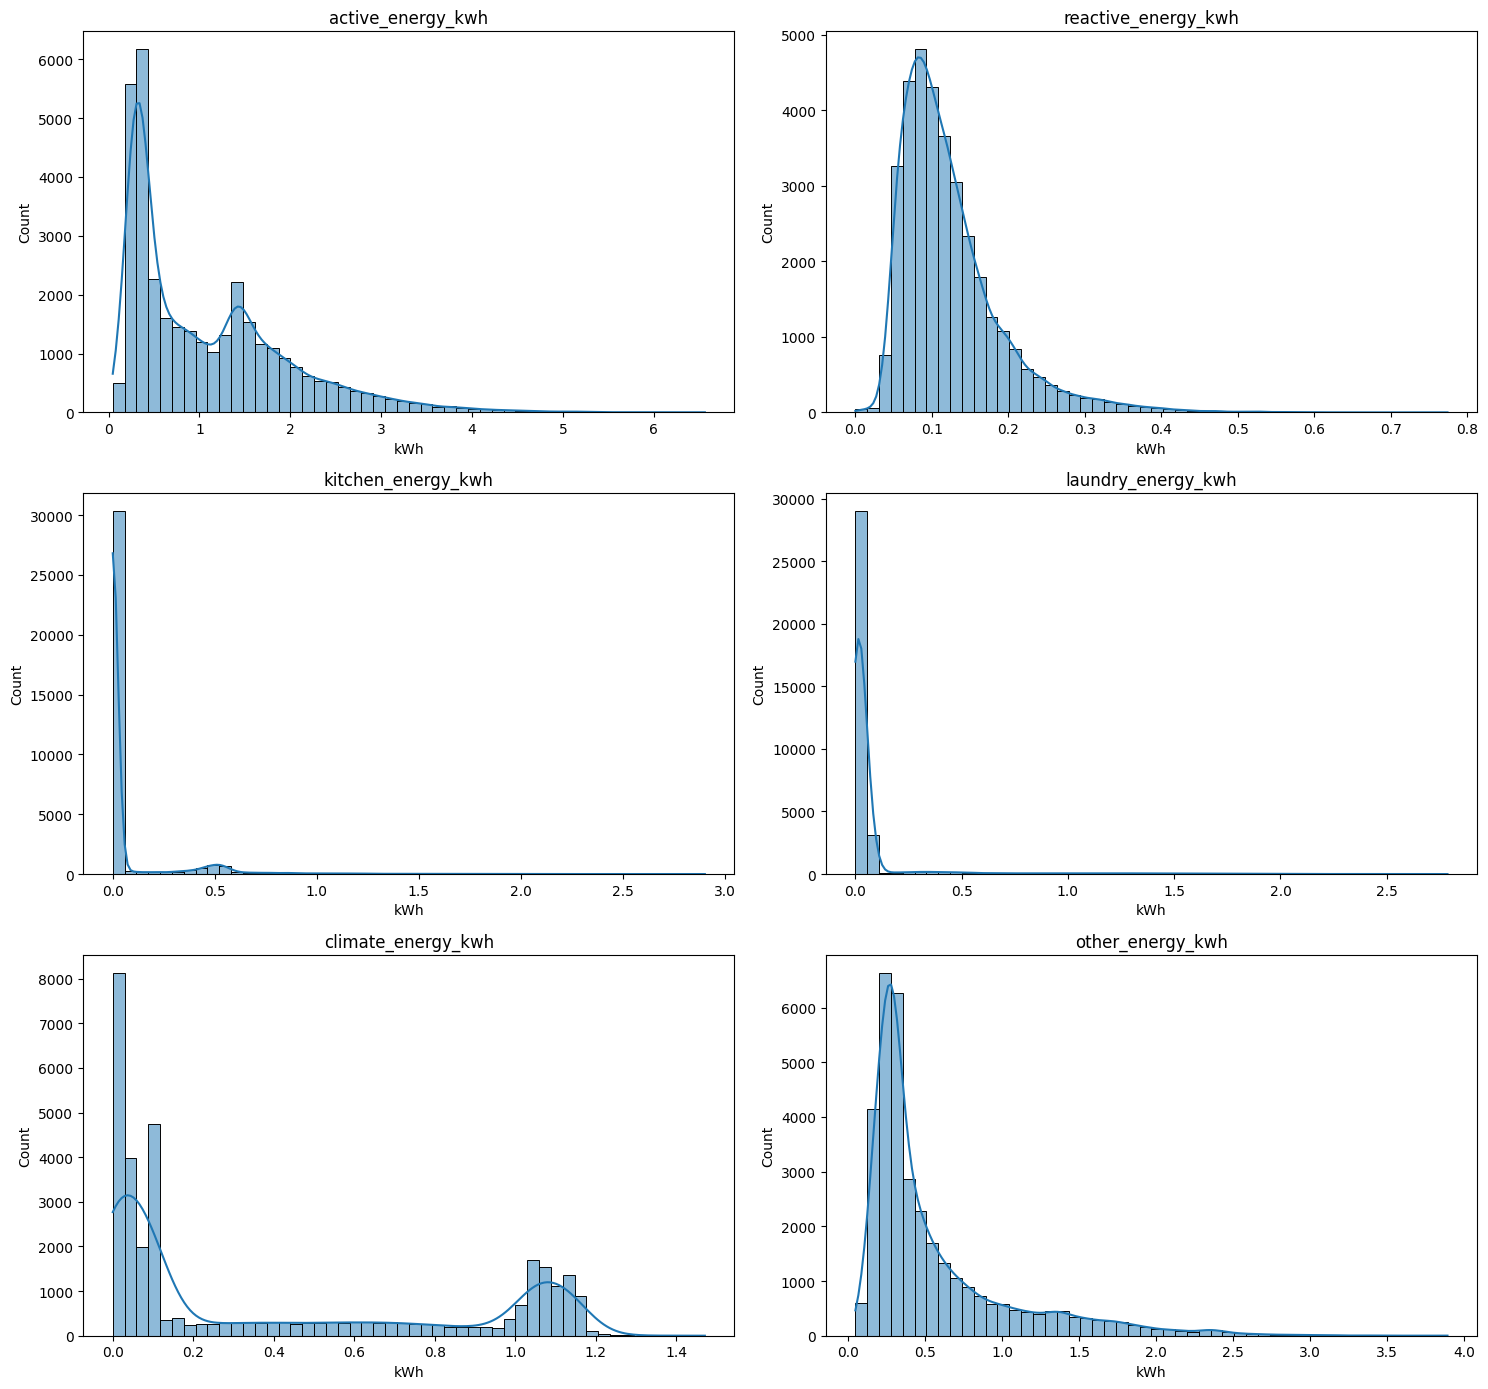

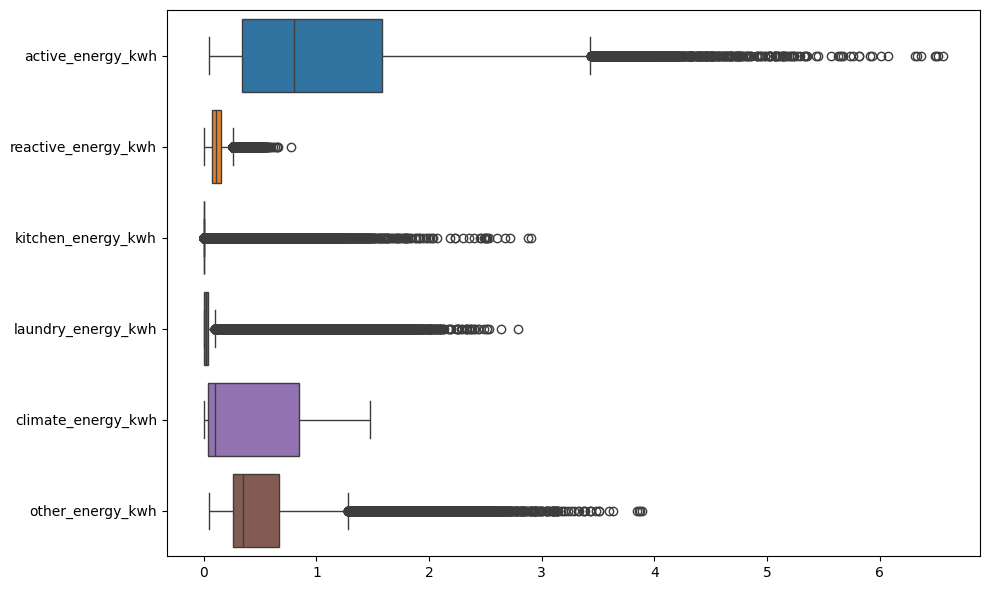

In [44]:
# distribution of energy measurements 
energy_cols = [
    "active_energy_kwh", "reactive_energy_kwh",
    "kitchen_energy_kwh", "laundry_energy_kwh",
    "climate_energy_kwh", "other_energy_kwh"
]

fig, axes = plt.subplots(3, 2, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(energy_cols):
    sns.histplot(
        df[col],
        bins=50,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("kWh")

plt.tight_layout()
plt.show()

# boxplots of energy variables
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df[energy_cols],
    orient="h"
)
plt.tight_layout()
plt.show()


The distribution of all energy-related variables is strongly right-skewed and clearly deviates from normality.
Most observations are concentrated at low consumption levels, while a limited number of hours exhibit very high energy usage, resulting in long right tails.

Several sub-metering variables are zero-inflated, reflecting the intermittent usage of specific appliances (e.g., kitchen, laundry, climate systems), which are inactive during most hours and produce consumption spikes only when in use.

Voltage, in contrast, shows limited variability and a stable distribution over time.

The presence of extreme values is consistent with genuine high-consumption events rather than data errors.

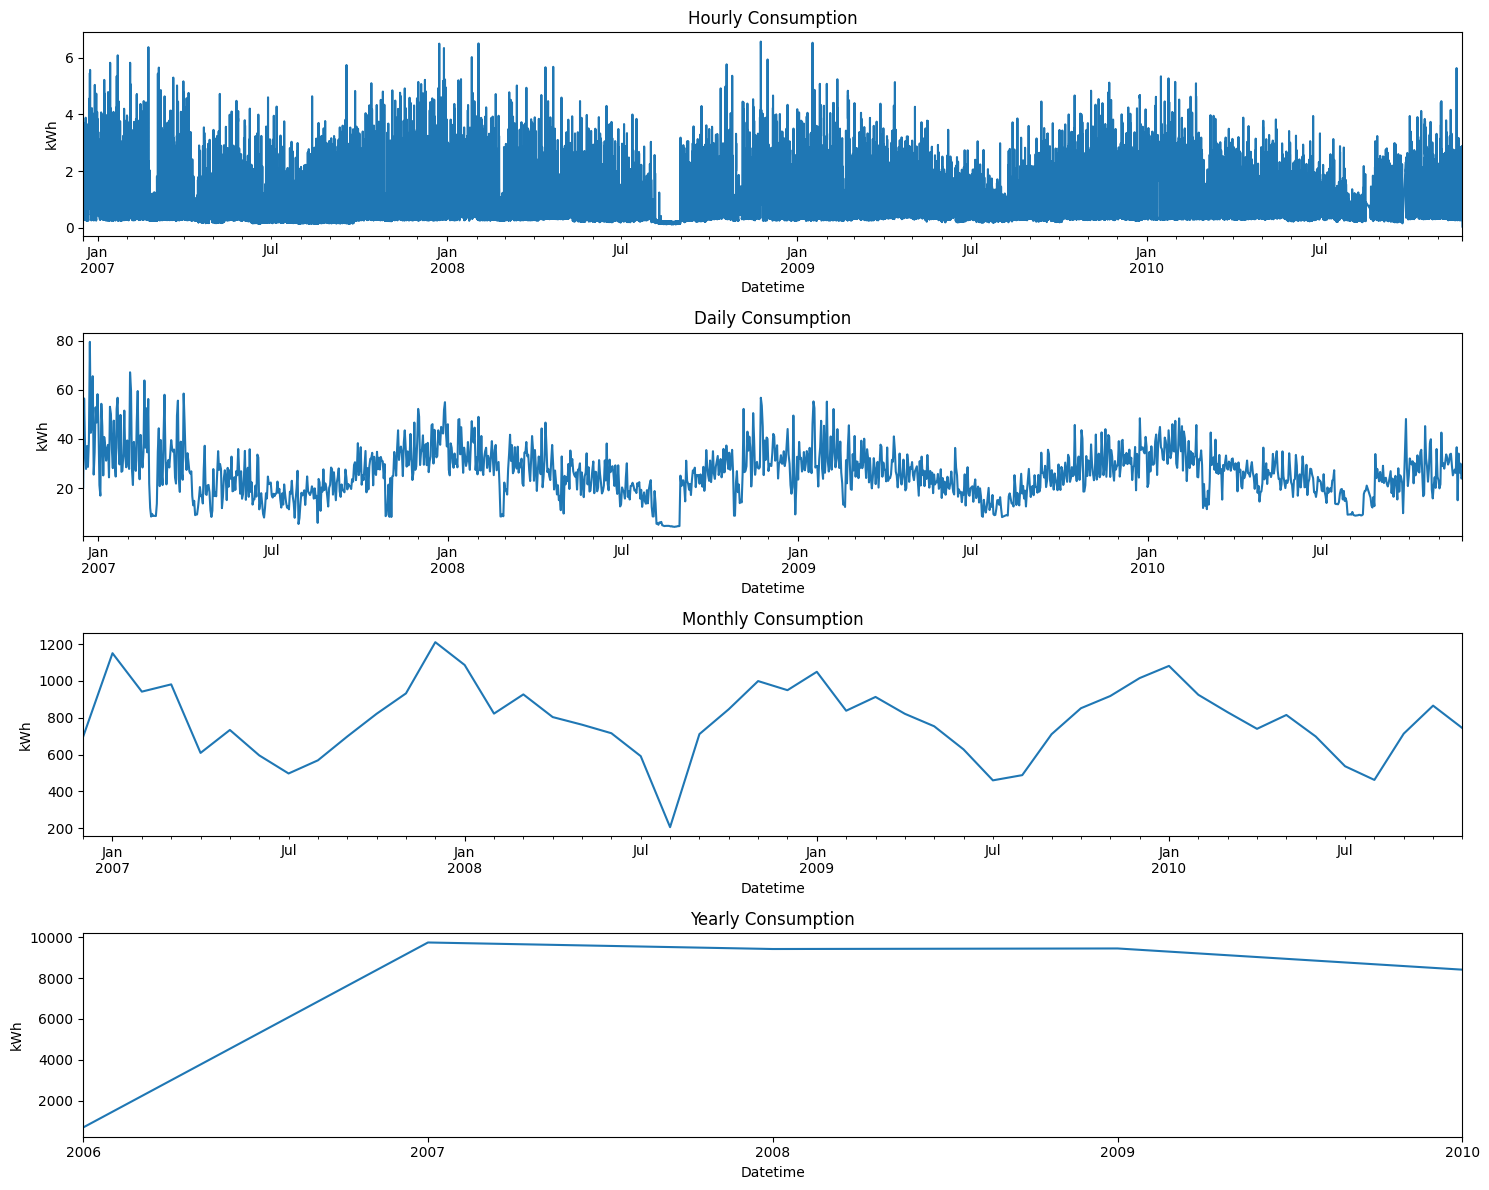

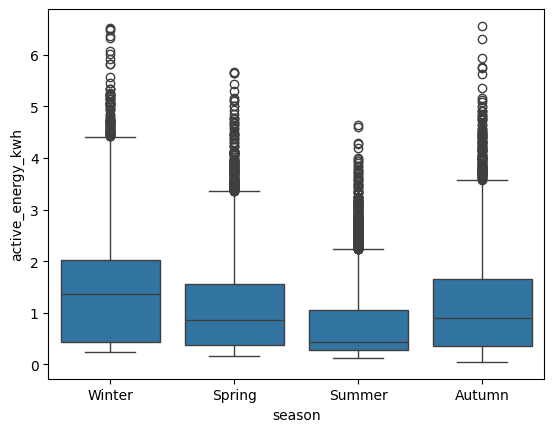

In [45]:
# Active energy consumption over time

# create datasets for ploting
df_daily = df['active_energy_kwh'].resample("D").sum()  # daily
df_monthly = df['active_energy_kwh'].resample("ME").sum() # monthly
df_yearly = df['active_energy_kwh'].resample("YE").sum()   # yearly

# plots
fig, axes = plt.subplots(4, 1, figsize=(15,12), sharex=False)

df['active_energy_kwh'].plot(ax=axes[0], title="Hourly Consumption")
df_daily.plot(ax=axes[1], title="Daily Consumption")
df_monthly.plot(ax=axes[2], title="Monthly Consumption")
df_yearly.plot(ax=axes[3], title="Yearly Consumption")

for ax in axes:
    ax.set_ylabel("kWh")

plt.tight_layout()
plt.show()


# boxplot seasonality
sns.boxplot(x='season', y='active_energy_kwh', data=df)
plt.show()




The plots show high hourly and daily variability in active energy consumption, reflecting short-term fluctuations in household electricity usage. 

At the monthly aggregation level a clear seasonal pattern can be seen, with higher energy consumption during the winter months and lower consumption in summer. This pattern is also confirmed by the distribution in the boxplot above.  

On a yearly basis, total energy consumption seems to be relatively stable across the observation period. The apparent increase from 2006 and 2007 is not representative of real increase in consumption as data for 2006 only include the last 14 days of the year.

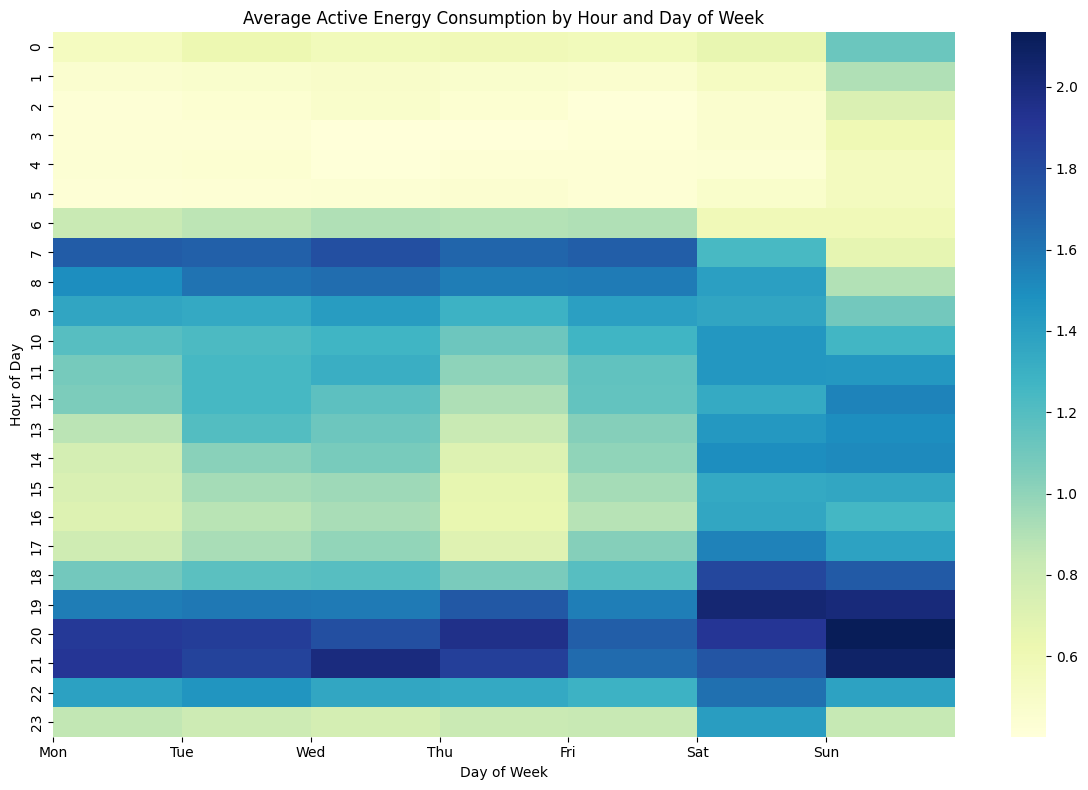

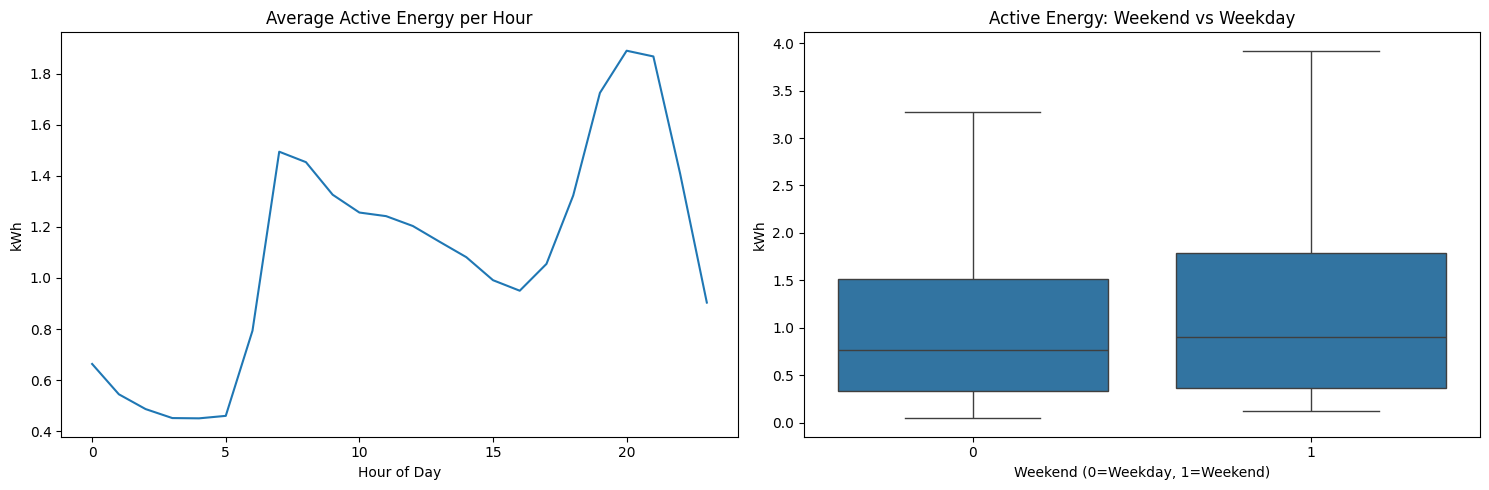

In [46]:
# Heatmap: hour vs day of week
plt.figure(figsize=(12, 8))

pivot = df.pivot_table(
    index='hour',
    columns='dayofweek',
    values='active_energy_kwh',
    aggfunc='mean'
)

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Average Active Energy Consumption by Hour and Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Hour of Day")
plt.xticks(
    ticks=range(7),
    labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
)

plt.tight_layout()
plt.show()



fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Average hourly profile
df.groupby('hour')['active_energy_kwh'].mean().plot(
    ax=axes[0]
)
axes[0].set_title("Average Active Energy per Hour")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("kWh")

# Weekend vs Weekday boxplot
sns.boxplot(
    x='weekend',
    y='active_energy_kwh',
    data=df,
    showfliers=False,
    ax=axes[1]
)
axes[1].set_title("Active Energy: Weekend vs Weekday")
axes[1].set_xlabel("Weekend (0=Weekday, 1=Weekend)")
axes[1].set_ylabel("kWh")

plt.tight_layout()
plt.show()




The heatmap reveals differences in electricity consumption behavior between weekends and working days.

Across all days of the week, consistently low average consumption levels are observed during nighttime hours, corresponding to typical sleeping schedules. Notable differences emerge in the early morning (~ 6–8 a.m.), where energy consumption is higher on weekdays, likely reflecting school and work-related activities.

During weekends, energy consumption appears more evenly distributed throughout the day, whereas on weekdays relatively lower consumption levels are observed during early afternoon hours (approximately 13–17). Peak consumption is concentrated in the evening hours (19–21), with the highest levels observed on Sundays. These patterns are further confirmed by the average hourly consumption profile shown in the line plot.

The boxplot comparison highlights a slightly higher median energy consumption on weekends compared to working days, as well as increased variability.
 

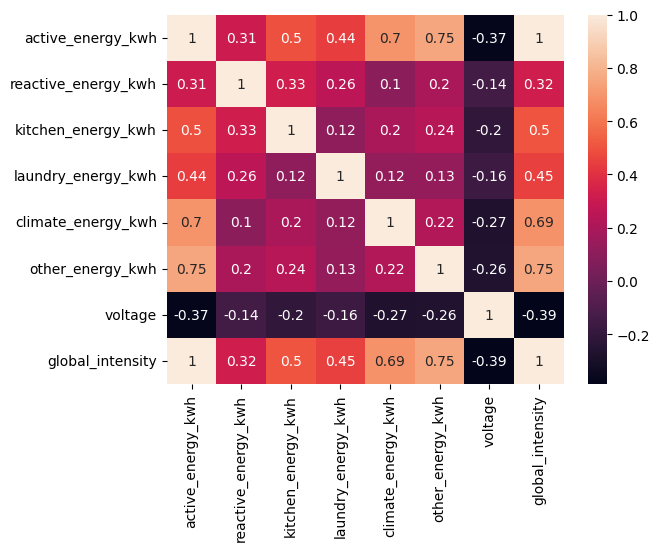

In [47]:
# correlation heatmap
sns.heatmap(df[energy_cols + ['voltage','global_intensity']].corr(), annot=True)
plt.show()


The correlation heatmap highlights several meaningful relationships among the variables.

- Voltage exhibits moderate negative correlations with all energy-related variables. This behavior is expected, as higher voltage levels typically correspond to lower current intensity for a given power demand, resulting in an inverse relationship with energy consumption.

- Global intensity and total active energy are perfectly positively correlated (corr = 1). The two variables represent the same underlying physical quantity expressed through closely related measurements, giving redundant information. 

- All energy consumption components expressed in kWh are positively correlated with each other. In particular, climate energy consumption (corr = 0.69) and other energy consumption (corr = 0.75) show strong correlations with the target variable active energy. This suggests that these components represent a substantial share of total household energy usage and are key drivers of overall consumption.

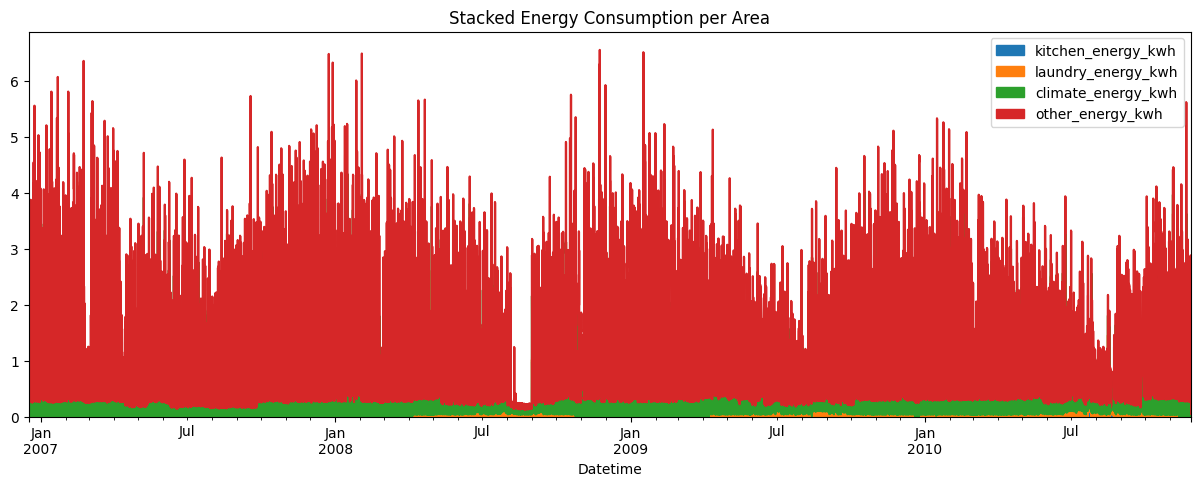

In [48]:
# stacked energy consumption plot
df[['kitchen_energy_kwh','laundry_energy_kwh','climate_energy_kwh','other_energy_kwh']].plot.area(figsize=(15,5))
plt.title("Stacked Energy Consumption per Area")
plt.show()


The stacked area plot illustrates the contribution of different household areas to total energy consumption over time. Kitchen and laundry appliances account for only a small fraction of overall energy usage, reflecting their intermittent and short-duration operation.

Climate-related consumption represents a larger share compared to kitchen and laundry, likely due to the use of energy-intensive appliances such as electric water heaters and air conditioning.

However, the largest contribution to total energy consumption originates from the remaining household areas, which include appliances and electrical loads not explicitly captured by the sub-metering variables. This component consistently dominates overall energy usage and plays a key role in determining total demand of energy.

### 5. Feature selection, temporal encoding & dataset splitting

To prepare the dataset for modeling, in this section we will: 

- encode temporal features (hour of day and day of week) as cycles using sine and cosine transformations. 

- remove raw calendar variables such as date, time, hour, and day of week, as they become redundant. Additionally, global_intensity will be excluded due to perfect correlation with the target variable, to prevent information leakage.

- split the dataset into train/test/val for machine learning models and train/test for time series models. To ensure fair comparison between classical time series models (SARIMA/ETS) and machine learning models (LSTM, XGBoost), the test set is kept identical for all approaches. 
All splits respect the temporal order of the data.


In [49]:
df_eda = df.copy()   # dataset used for EDA

# cyclic encoding
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

# one-hot encoding
df = pd.get_dummies(df, columns=['season'], drop_first=True)

# remove variables
df = df.drop(columns=[
    'date',
    'time',
    'hour',
    'dayofweek',
    'global_intensity'
])

# check
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34589 entries, 2006-12-16 17:00:00 to 2010-11-26 21:00:00
Freq: h
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   weekend              34589 non-null  int64  
 1   active_energy_kwh    34589 non-null  float64
 2   reactive_energy_kwh  34589 non-null  float64
 3   voltage              34589 non-null  float64
 4   kitchen_energy_kwh   34589 non-null  float64
 5   laundry_energy_kwh   34589 non-null  float64
 6   climate_energy_kwh   34589 non-null  float64
 7   other_energy_kwh     34589 non-null  float64
 8   was_interpolated     34589 non-null  bool   
 9   hour_sin             34589 non-null  float64
 10  hour_cos             34589 non-null  float64
 11  dow_sin              34589 non-null  float64
 12  dow_cos              34589 non-null  float64
 13  season_Spring        34589 non-null  bool   
 14  season_Summer        34589 non-null  bool  

,weekend,active_energy_kwh,reactive_energy_kwh,voltage,kitchen_energy_kwh,laundry_energy_kwh,climate_energy_kwh,other_energy_kwh,was_interpolated,hour_sin,hour_cos,dow_sin,dow_cos,season_Spring,season_Summer,season_Winter
Datetime,,,,,,,,,,,,,,,,
2006-12-16 17:00:00,1,2.533733,0.137400,234.643889,0.0,0.019,0.607,1.907733,False,-0.965926,-2.588190e-01,-0.974928,-0.222521,False,False,True
2006-12-16 18:00:00,1,3.632200,0.080033,234.580167,0.0,0.403,1.012,2.217200,False,-1.000000,-1.836970e-16,-0.974928,-0.222521,False,False,True
2006-12-16 19:00:00,1,3.400233,0.085233,233.232500,0.0,0.086,1.001,2.313233,False,-0.965926,2.588190e-01,-0.974928,-0.222521,False,False,True
2006-12-16 20:00:00,1,3.268567,0.075100,234.071500,0.0,0.000,1.007,2.261567,False,-0.866025,5.000000e-01,-0.974928,-0.222521,False,False,True
2006-12-16 21:00:00,1,3.056467,0.076667,237.158667,0.0,0.025,1.033,1.998467,False,-0.707107,7.071068e-01,-0.974928,-0.222521,False,False,True


In [50]:
# splitting (70/15/15)

# common test set (last 15%)
n = len(df)
test_size = int(n * 0.15)  
test = df.iloc[-test_size:] 

# train/val for ML 
train_val = df.iloc[:-test_size]  
ratio_train_val = 70 / 85  # ≈ 0.8235
train_size = int(len(train_val) * ratio_train_val)
train = train_val.iloc[:train_size]
val   = train_val.iloc[train_size:]

# train for SARIMA and ETS
train_sarima = train_val['active_energy_kwh']
test_sarima  = df.iloc[-test_size:]['active_energy_kwh']

print("ML/DL splits:")
print(f"Train: {train.index.min()} -> {train.index.max()} ({len(train)} rows)")
print(f"Validation: {val.index.min()} -> {val.index.max()} ({len(val)} rows)")
print(f"Test: {test.index.min()} -> {test.index.max()} ({len(test)} rows)")
print("-"*60)
print("\nSARIMA/ETS splits:")
print(f"Train: {train_sarima.index.min()} -> {train_sarima.index.max()} ({len(train_sarima)} rows)")
print(f"Test: {test_sarima.index.min()} -> {test_sarima.index.max()} ({len(test_sarima)} rows)")


ML/DL splits:
Train: 2006-12-16 17:00:00 -> 2009-09-20 12:00:00 (24212 rows)
Validation: 2009-09-20 13:00:00 -> 2010-04-24 17:00:00 (5189 rows)
Test: 2010-04-24 18:00:00 -> 2010-11-26 21:00:00 (5188 rows)
------------------------------------------------------------

SARIMA/ETS splits:
Train: 2006-12-16 17:00:00 -> 2010-04-24 17:00:00 (29401 rows)
Test: 2010-04-24 18:00:00 -> 2010-11-26 21:00:00 (5188 rows)


### 6. Naive baselines

Two naive benchmarks were considered: a persistence model assuming the next-hour load equals the current one, and a seasonal naive model using the consumption observed at the same hour one year earlier.

We calculate the error metrics for this Naive model as a baseline to evaluate more sophisticated models. 

Random Walk baseline metrics:
MAE:  0.373 kWh
RMSE: 0.575 kWh
MAPE: 45.22 %
------------------------------------------------------------

Seasonal Naive baseline metrics:
MAE:  0.563 kWh
RMSE: 0.820 kWh
MAPE: 76.46 %


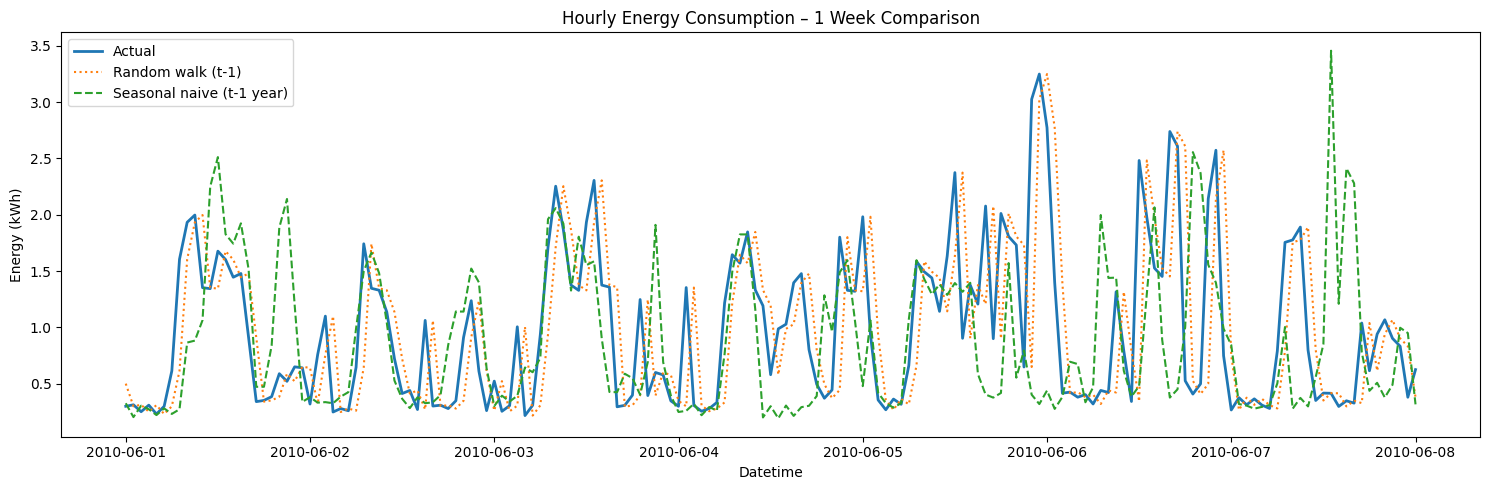

In [51]:
# random walk (persistence baseline)
rw_pred = test_sarima.shift(1)

# align (drop first NaN)
mask = rw_pred.notna()

mae_rw = mean_absolute_error(test_sarima[mask], rw_pred[mask])
rmse_rw = np.sqrt(mean_squared_error(test_sarima[mask], rw_pred[mask]))
mape_rw = np.mean(
    np.abs((test_sarima[mask] - rw_pred[mask]) / test_sarima[mask])
) * 100

print(f"Random Walk baseline metrics:")
print(f"MAE:  {mae_rw:.3f} kWh")
print(f"RMSE: {rmse_rw:.3f} kWh")
print(f"MAPE: {mape_rw:.2f} %")
print("-"*60)


# naive baseline using previous year same period
baseline_pred = df.loc['2009-04-24 18:00:00':'2009-11-26 21:00:00', 'active_energy_kwh'].values

# check lengths
assert len(baseline_pred) == len(test_sarima), "Lengths must match"

# metrics
mae_naive = mean_absolute_error(test_sarima, baseline_pred)
rmse_naive = np.sqrt(mean_squared_error(test_sarima, baseline_pred))
mape_naive = np.mean(np.abs((test_sarima - baseline_pred) / test_sarima)) * 100

print("\nSeasonal Naive baseline metrics:")
print(f"MAE:  {mae_naive:.3f} kWh")
print(f"RMSE: {rmse_naive:.3f} kWh")
print(f"MAPE: {mape_naive:.2f} %")


# plots

start = "2010-06-01"
end = pd.to_datetime(start) + pd.Timedelta(days=7)

actual = test_sarima.loc[start:end]
rw = test_sarima.shift(1).loc[start:end]

seasonal = pd.Series(
    baseline_pred,
    index=test_sarima.index
).loc[start:end]

plt.figure(figsize=(15,5))

plt.plot(actual, label="Actual", linewidth=2)
plt.plot(rw, label="Random walk (t-1)", linestyle=":")
plt.plot(seasonal, label="Seasonal naive (t-1 year)", linestyle="--")

plt.title("Hourly Energy Consumption – 1 Week Comparison")
plt.ylabel("Energy (kWh)")
plt.xlabel("Datetime")
plt.legend()
plt.tight_layout()
plt.show()

The random walk baseline achieves a MAPE of 45.22%, indicating that although hourly consumption exhibits short-term continuity, relying solely on the previous hour’s value is insufficient to accurately capture the dynamics of next-hour demand. This reflects the presence of abrupt changes and intra-day variability that cannot be explained by last hour's consumption alone.

The seasonal naive baseline performs considerably worse (MAPE: 76.46%), as hourly consumption patterns show limited reproducibility across years due to substantial variability in daily usage patterns.

Overall, these results highlight the need for models that can simultaneously capture recent dynamics and calendar-related effects.

### XGBoost 

In this section, we apply XGBoost, a gradient boosting tree-based algorithm, to forecast short-term hourly energy consumption. XGBoost is particularly suited for tabular data with lagged features and temporal patterns, allowing the model to capture non-linear relationships and interactions between past consumption, calendar features, and derived lags. We aim to evaluate whether XGBoost can improve predictions compared to simple baselines like the Random Walk and Seasonal Naive models.

Before training XGBoost, we need to prepare the dataset with lagged features and calendar variables to capture temporal dependencies in hourly energy consumption and to ensure temporal continuity between train, validation, and test sets, avoiding data loss or misalignment.

Finally, unnecessary columns from the original dataset are dropped, and all rows with missing values due to shifting or lagging are removed.

In [52]:
# prepare the dataset for XGB

# helper function
def prepare_xgb_dataset(df, 
                                   target_col="active_energy_kwh", 
                                   lags=(1, 24, 48, 168),
                                   idx_start=None):
    """
    Prepares the dataset for XGBoost mantaining temporal continuity between split.

    Parameters:
    - df: dataframe (train, train+val, or val+test)
    - target_col: y
    - lags: lagging variables
    - idx_start: optional, index of first row to use as final dataset

    Returns:
    - df ready for XGBoost
    """

    df = df.copy()

    # 1. Target t+1
    df["y"] = df[target_col].shift(-1)

    # 2. Lag of target variable
    for lag in lags:
        df[f"y_lag_{lag}"] = df[target_col].shift(lag)

    # 3. Calendar features for y t+1
    idx_out = df.index + pd.Timedelta(hours=1)
    hour = idx_out.hour
    dow = idx_out.dayofweek
    month = idx_out.month

    df["hour_out_sin"] = np.sin(2 * np.pi * hour / 24)
    df["hour_out_cos"] = np.cos(2 * np.pi * hour / 24)
    df["dow_out_sin"] = np.sin(2 * np.pi * dow / 7)
    df["dow_out_cos"] = np.cos(2 * np.pi * dow / 7)
    df["weekend_out"] = (dow >= 5).astype(int)

    # Season (autumn baseline)
    df["season_spring"] = month.isin([3,4,5]).astype(int)
    df["season_summer"] = month.isin([6,7,8]).astype(int)
    df["season_winter"] = month.isin([12,1,2]).astype(int)

    # 4. Drop unecessary columns 
    drop_cols = [
        target_col,
        "hour_sin","hour_cos",
        "dow_sin","dow_cos",
        "weekend",
        "season_Spring","season_Summer","season_Winter",
        "was_interpolated"
    ]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    # 5. Drop NaN 
    df = df.dropna()

    # 6. If specified, take the rows starting from idx_start
    if idx_start is not None:
        df = df.loc[df.index >= idx_start]

    return df


# X and y train 
train_xgb = prepare_xgb_dataset(train)
X_train = train_xgb.drop(columns=["y"])
y_train = train_xgb["y"]

# X and y validation
# include last 168 hours of train + val
val_extended = pd.concat([train.iloc[-168:], val])
val_xgb = prepare_xgb_dataset(val_extended, idx_start=val.index.min())
X_val = val_xgb.drop(columns=["y"])
y_val = val_xgb["y"]

# X and y validation
# include last 168 hours of train + val
test_extended = pd.concat([val.iloc[-168:], test])
test_xgb = prepare_xgb_dataset(test_extended, idx_start=test.index.min())
X_test = test_xgb.drop(columns=["y"])
y_test = test_xgb["y"]


# check
assert X_train.index.is_monotonic_increasing
assert X_val.index.is_monotonic_increasing
assert X_test.index.is_monotonic_increasing

print("COLUMNS in X:")
print("-"*60)
print(X_train.columns)

print("\nX and y shape: ")
print("-"*60)
print(f"X_train shape:{X_train.shape}")
print(f"y_train shape:{y_train.shape}")
print(f"X_val shape:{X_val.shape}")
print(f"y_val shape:{y_val.shape}")
print(f"X_test shape:{X_test.shape}")
print(f"y_test shape:{y_test.shape}")


COLUMNS in X:
------------------------------------------------------------
Index(['reactive_energy_kwh', 'voltage', 'kitchen_energy_kwh',
       'laundry_energy_kwh', 'climate_energy_kwh', 'other_energy_kwh',
       'y_lag_1', 'y_lag_24', 'y_lag_48', 'y_lag_168', 'hour_out_sin',
       'hour_out_cos', 'dow_out_sin', 'dow_out_cos', 'weekend_out',
       'season_spring', 'season_summer', 'season_winter'],
      dtype='object')

X and y shape: 
------------------------------------------------------------
X_train shape:(24043, 18)
y_train shape:(24043,)
X_val shape:(5188, 18)
y_val shape:(5188,)
X_test shape:(5187, 18)
y_test shape:(5187,)


In [53]:
# 1. Defining XGBoost model
xgb_model = XGBRegressor(
    n_estimators=1000,        # max num of trees
    max_depth=6,              # max depth for each tree
    learning_rate=0.05,       # learning rate
    subsample=0.8,            # % of observations considered for each row
    colsample_bytree=0.8,       # % of features considered for each row
    objective="reg:squarederror",
    random_state=42,          # random seed
    n_jobs=-1,                # use all CPU core
    eval_metric="rmse",
    early_stopping_rounds=50   # stops earlier if no improvements after 50 rounds
)

# 2. Training with early stopping
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)

# 3. Predictions on test set
y_pred_xgb = xgb_model.predict(X_test)

# 4. XGB evaluation metrics
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100

print("XGBoost test metrics:")
print(f"MAE:  {mae_xgb:.3f} kWh")
print(f"RMSE: {rmse_xgb:.3f} kWh")
print(f"MAPE: {mape_xgb:.2f} %")

[0]	validation_0-rmse:1.11723
[1]	validation_0-rmse:1.07606
[2]	validation_0-rmse:1.03838
[3]	validation_0-rmse:1.00266
[4]	validation_0-rmse:0.97007
[5]	validation_0-rmse:0.94032
[6]	validation_0-rmse:0.91154
[7]	validation_0-rmse:0.88392
[8]	validation_0-rmse:0.85931
[9]	validation_0-rmse:0.83626
[10]	validation_0-rmse:0.81528
[11]	validation_0-rmse:0.79541
[12]	validation_0-rmse:0.77733
[13]	validation_0-rmse:0.75996
[14]	validation_0-rmse:0.74196
[15]	validation_0-rmse:0.72437
[16]	validation_0-rmse:0.71033
[17]	validation_0-rmse:0.69497
[18]	validation_0-rmse:0.68192
[19]	validation_0-rmse:0.66837
[20]	validation_0-rmse:0.65613
[21]	validation_0-rmse:0.64493
[22]	validation_0-rmse:0.63690
[23]	validation_0-rmse:0.62749
[24]	validation_0-rmse:0.61841
[25]	validation_0-rmse:0.60984
[26]	validation_0-rmse:0.60290
[27]	validation_0-rmse:0.59583
[28]	validation_0-rmse:0.58944
[29]	validation_0-rmse:0.58306
[30]	validation_0-rmse:0.57746
[31]	validation_0-rmse:0.57282
[32]	validation_0-

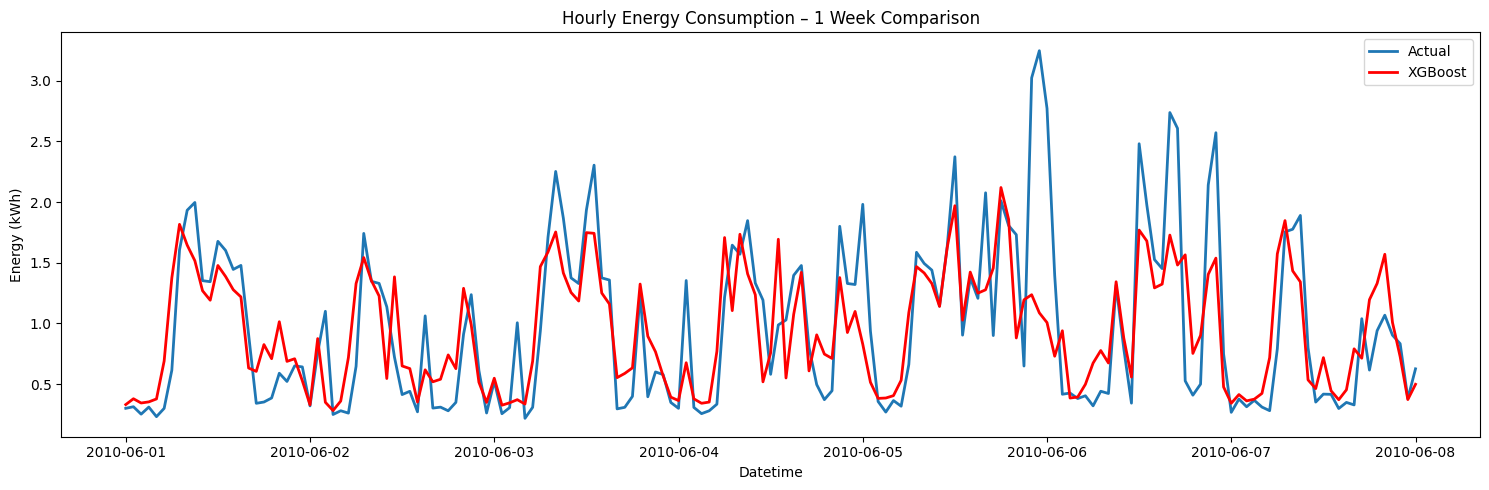

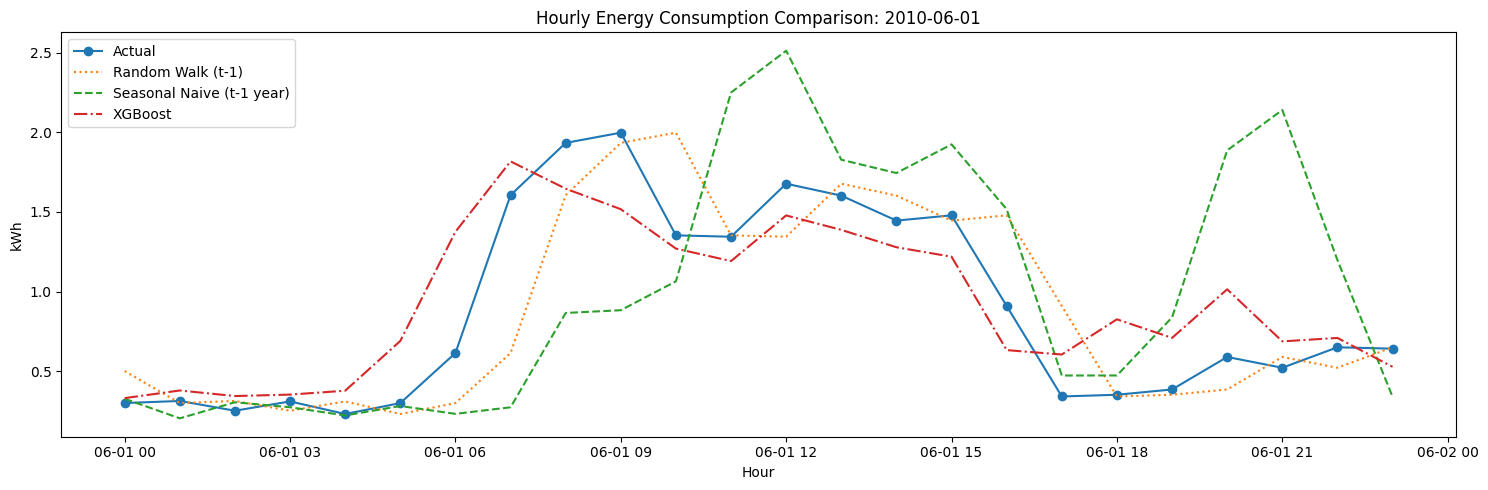

XGBoost test metrics:
MAE:  0.316 kWh
RMSE: 0.452 kWh
MAPE: 42.06 %
------------------------------------------------------------

Random Walk baseline metrics:
MAE:  0.373 kWh
RMSE: 0.575 kWh
MAPE: 45.22 %
------------------------------------------------------------

Seasonal Naive baseline metrics:
MAE:  0.563 kWh
RMSE: 0.820 kWh
MAPE: 76.46 %


In [54]:
# plots
import matplotlib.pyplot as plt
import pandas as pd

# 1. Period of interest
start = "2010-06-01"
end = pd.to_datetime(start) + pd.Timedelta(days=7)

# Allign index
xgb_index = X_test.index  

# 2. Allign series
# XGBoost
xgb_series = pd.Series(y_pred_xgb, index=xgb_index, name="XGBoost").loc[start:end]

# Random Walk baseline
rw_aligned = rw_pred.loc[xgb_index].loc[start:end]

# Seasonal naive
seasonal_aligned = pd.Series(baseline_pred, index=test_sarima.index).loc[xgb_index].loc[start:end]

# Actual
actual_aligned = test_sarima.loc[xgb_index].loc[start:end]


# 1 week comparison
plt.figure(figsize=(15,5))
plt.plot(actual_aligned, label="Actual", linewidth=2)
plt.plot(xgb_series, label="XGBoost", color='red', linewidth=2)
plt.title("Hourly Energy Consumption – 1 Week Comparison")
plt.ylabel("Energy (kWh)")
plt.xlabel("Datetime")
plt.legend()
plt.tight_layout()
plt.show()

# Single day comparison (24 hours)
day_start = pd.to_datetime(start)
day_end = day_start + pd.Timedelta(hours=23)

plt.figure(figsize=(15,5))
plt.plot(actual_aligned.loc[day_start:day_end], label="Actual", marker='o')
plt.plot(rw_aligned.loc[day_start:day_end], label="Random Walk (t-1)", linestyle=':')
plt.plot(seasonal_aligned.loc[day_start:day_end], label="Seasonal Naive (t-1 year)", linestyle='--')
plt.plot(xgb_series.loc[day_start:day_end], label="XGBoost", linestyle='-.')
plt.title(f"Hourly Energy Consumption Comparison: {day_start.date()}")
plt.ylabel("kWh")
plt.xlabel("Hour")
plt.legend()
plt.tight_layout()
plt.show()



# metrics comparison report
print("XGBoost test metrics:")
print(f"MAE:  {mae_xgb:.3f} kWh")
print(f"RMSE: {rmse_xgb:.3f} kWh")
print(f"MAPE: {mape_xgb:.2f} %")
print("-"*60)

print("\nRandom Walk baseline metrics:")
print(f"MAE:  {mae_rw:.3f} kWh")
print(f"RMSE: {rmse_rw:.3f} kWh")
print(f"MAPE: {mape_rw:.2f} %")
print("-"*60)

print("\nSeasonal Naive baseline metrics:")
print(f"MAE:  {mae_naive:.3f} kWh")
print(f"RMSE: {rmse_naive:.3f} kWh")
print(f"MAPE: {mape_naive:.2f} %")

XGBoost outperforms random walk and the plot zoomed into a random day, we can see how it can predict really well the pattern of consumption even if not the exact value. Due to the high variability in hourly consumption across different days, it is really difficult to capture signal from random noise.   

XGBoost outperforms both the Random Walk and the Seasonal Naive baseline, reducing absolute and percentage errors.
From the zoomed-in plots, we can see that XGBoost captures the hourly consumption pattern well, following peaks and dips, even if it does not always predict the exact value.

The main challenge is the high variability in hourly consumption, which contains significant random noise; this explains why the MAPE remains above 40%.

These results suggest that for short-term energy forecasting, the last-value baseline is already quite competitive, and meaningful improvements require additional features or models with longer memory, such as LSTMs.